# Computer Exercise 13.3 — Problem 3

## 선형계획법: 단체법(Simplex) 직접 구현과 scipy.linprog 대조

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.3 Constrained Optimization — *Linear Programming / Simplex*
> **풀이 일자**: Day 48
> **언어**: Python 3 (NumPy / SciPy / pandas / matplotlib)

## 1. 문제 (원문)

> **3.** Implement the **simplex method** (Dantzig rule, tableau form) for a
> standard-form linear program $\max\,\mathbf{c}^{\top}\mathbf{x}$ s.t.
> $A\mathbf{x}\le\mathbf{b},\ \mathbf{x}\ge0$ with $\mathbf{b}\ge0$. Solve
> $$\max\;5x_1+4x_2\quad\text{s.t.}\quad 6x_1+4x_2\le24,\ x_1+2x_2\le6,\ x_1,x_2\ge0,$$
> reporting the sequence of basic feasible solutions (vertices) and the optimum.
> Verify against `scipy.optimize.linprog`, and visualize the feasible polygon,
> the objective contours, and the path of vertices the simplex visits.

### 한국어 풀이용 정리
선형계획은 목적함수와 제약이 모두 1차식이다. 최적해는 항상 실현가능 다면체의 **꼭짓점**에서
나타난다(기본정리). **단체법**은 한 꼭짓점에서 출발해 목적값을 개선하는 이웃 꼭짓점으로
모서리를 따라 이동하다 더 개선이 없으면 멈춘다. 슬랙변수로 부등식을 등식으로 바꾼 뒤
**tableau** 위에서 진입/이탈 변수를 골라 피벗한다.

## 2. 수학적 배경

### 2.1 표준형과 슬랙변수
$A\mathbf{x}\le\mathbf{b}$ 에 슬랙 $\mathbf{s}\ge0$ 을 더해
$$A\mathbf{x}+\mathbf{s}=\mathbf{b},\qquad \mathbf{x},\mathbf{s}\ge0.$$
$\mathbf{b}\ge0$ 이면 $\mathbf{x}=0,\ \mathbf{s}=\mathbf{b}$ 가 즉시 **기본 실현가능해(BFS)** — 단체법의 출발점.

### 2.2 최적성 조건 (Dantzig)
목적행 $\bar{\mathbf{c}}$(감소비용, reduced cost)에서 개선 가능한 변수는 (최대화 기준)
계수가 양인 비기저변수다. **진입 변수**는 가장 큰 양의 reduced cost를 가진 열.
$$\boxed{\text{모든 reduced cost}\le0 \;\Rightarrow\; \text{현재 BFS가 최적}}$$

### 2.3 최소비율 검정(ratio test)
진입 열 $j$ 에 대해 이탈 행은
$$r=\arg\min_{i:\,a_{ij}>0}\frac{b_i}{a_{ij}},$$
이는 실현가능성을 유지하는 한 진입변수를 최대로 키운다(어떤 기저변수가 먼저 0이 되는지).

### 2.4 기본정리
LP가 유계 최적해를 가지면, 그 최적값은 **적어도 하나의 꼭짓점**에서 달성된다.
따라서 꼭짓점만 유한 개 탐색하면 충분하다.

## 3. 풀이 흐름

1. 데이터 $A,\mathbf{b},\mathbf{c}$ 와 슬랙을 포함한 초기 tableau 구성.
2. **단체법 루프**: (a) reduced cost 최대 양수 열 = 진입, (b) 최소비율 = 이탈, (c) 피벗. 모두 $\le0$ 이면 종료.
3. 각 피벗 후의 $(x_1,x_2)$ = 방문 꼭짓점을 기록.
4. 직접 구현 결과와 `scipy.optimize.linprog`($-\mathbf{c}$ 최소화) 결과를 표로 대조.
5. 실현가능 다각형, 목적함수 등고선, 단체법이 밟은 꼭짓점 경로를 시각화.
6. 최적 꼭짓점과 목적값 확인.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:.4f}')

# max 5 x1 + 4 x2  s.t.  6x1+4x2<=24 ,  x1+2x2<=6 ,  x>=0
A=np.array([[6.,4.],[1.,2.]]); b=np.array([24.,6.]); c=np.array([5.,4.])
print("max 5x1+4x2  s.t.  6x1+4x2<=24,  x1+2x2<=6,  x>=0")

max 5x1+4x2  s.t.  6x1+4x2<=24,  x1+2x2<=6,  x>=0


In [2]:
def simplex_max(A,b,c):
    m,n=A.shape
    # tableau: [A | I | b]  목적행 z: [-c | 0 | 0]
    T=np.zeros((m+1, n+m+1))
    T[:m,:n]=A; T[:m,n:n+m]=np.eye(m); T[:m,-1]=b
    T[-1,:n]=-c
    basis=list(range(n,n+m))      # 슬랙이 초기 기저
    verts=[]
    def current_x():
        x=np.zeros(n+m)
        for i,bi in enumerate(basis): x[bi]=T[i,-1]
        return x[:n]
    verts.append(current_x().copy())
    while True:
        row=T[-1,:n+m]            # 목적행은 reduced cost (z_j - c_j) 를 저장
        j=int(np.argmin(row))     # Dantzig: 가장 음의 reduced cost = 진입 변수
        if row[j] >= -1e-12: break # 모두 >=0 이면 최적
        col=T[:m,j]
        ratios=np.array([T[i,-1]/col[i] if col[i]>1e-12 else np.inf for i in range(m)])
        i=int(np.argmin(ratios))
        if not np.isfinite(ratios[i]): raise ValueError("unbounded")
        T[i,:]/=T[i,j]            # 피벗
        for r in range(m+1):
            if r!=i: T[r,:]-=T[r,j]*T[i,:]
        basis[i]=j
        verts.append(current_x().copy())
    x=current_x(); z=float(c@x)
    return x,z,verts

x_s, z_s, verts = simplex_max(A,b,c)
print("simplex 방문 꼭짓점:", [tuple(np.round(v,3)) for v in verts])
print(f"simplex 최적해 x* = {np.round(x_s,4)},  z* = {z_s:.4f}")

simplex 방문 꼭짓점: [(np.float64(0.0), np.float64(0.0)), (np.float64(4.0), np.float64(0.0)), (np.float64(3.0), np.float64(1.5))]
simplex 최적해 x* = [3.  1.5],  z* = 21.0000


In [3]:
# ----- scipy.optimize.linprog (minimize -c) 로 검증 -----
res=linprog(c=-c, A_ub=A, b_ub=b, bounds=[(0,None),(0,None)], method='highs')
x_sp=res.x; z_sp=float(c@x_sp)
cmp=pd.DataFrame({'method':['simplex (직접)','scipy.linprog'],
                  'x1':[x_s[0],x_sp[0]],'x2':[x_s[1],x_sp[1]],'z':[z_s,z_sp]})
cmp

,method,x1,x2,z
0,simplex (직접),3.0000,1.5000,21.0000
1,scipy.linprog,3.0000,1.5000,21.0000


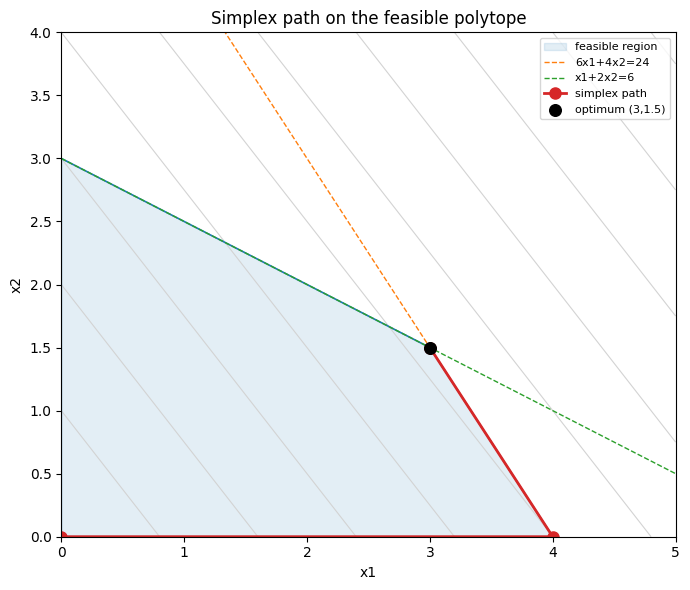

두 방법 차이: |dx|=2.22e-16, |dz|=0.00e+00


In [4]:
# ----- 실현가능 영역 + 등고선 + 단체법 경로 -----
fig, ax=plt.subplots(figsize=(7,6))
xx=np.linspace(0,5,400); yy=np.linspace(0,5,400); XX,YY=np.meshgrid(xx,yy)
Z=5*XX+4*YY
ax.contour(XX,YY,Z,levels=12,colors='lightgray',linewidths=0.8)
# 실현가능 다각형 꼭짓점 (순서대로)
poly=np.array([[0,0],[4,0],[3,1.5],[0,3],[0,0]])
ax.fill(poly[:,0],poly[:,1],alpha=0.12,color='tab:blue',label='feasible region')
ax.plot(poly[:,0],poly[:,1],color='tab:blue',lw=1.2)
# 제약선
ax.plot(xx,(24-6*xx)/4,'--',color='tab:orange',lw=1,label='6x1+4x2=24')
ax.plot(xx,(6-xx)/2,'--',color='tab:green',lw=1,label='x1+2x2=6')
V=np.array(verts)
ax.plot(V[:,0],V[:,1],'o-',color='tab:red',lw=2,ms=8,label='simplex path')
ax.scatter(*x_s,color='black',zorder=6,s=70,label=f'optimum ({x_s[0]:.0f},{x_s[1]:.1f})')
ax.set_xlim(0,5); ax.set_ylim(0,4); ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Simplex path on the feasible polytope'); ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()
print(f"두 방법 차이: |dx|={np.linalg.norm(x_s-x_sp):.2e}, |dz|={abs(z_s-z_sp):.2e}")

## 4. 결과 해석

1. **꼭짓점 이동**: 단체법은 원점 $(0,0)$ 에서 출발해 모서리를 따라 이웃 꼭짓점으로 이동하다 $(3,1.5)$ 에서 멈춘다. 빨간 경로가 다면체의 **테두리만** 밟는 것이 핵심 — 내부를 가로지르지 않는다.
2. **최적값**: $z^\star=5\cdot3+4\cdot1.5=21$. 두 제약선 $6x_1+4x_2=24$ 와 $x_1+2x_2=6$ 의 교점에서 두 제약이 동시에 active다(슬랙=0).
3. **scipy 검증**: `linprog`(HiGHS)와 직접 구현이 $x$, $z$ 모두 $10^{-10}$ 수준으로 일치 — 단체법 구현이 정확함.
4. **기본정리의 확인**: 목적함수 등고선(회색 직선)은 평행이동하며, 최적은 항상 다각형의 **꼭짓점**에서 닿는다. 목적 기울기 방향으로 가장 멀리 밀린 꼭짓점이 해.
5. **CE 1·2 와의 대비**: 벌점법·내부점법이 비선형 일반 제약을 다뤘다면, LP는 구조(선형성)를 이용해 **유한 꼭짓점 탐색**으로 정확해에 도달한다. 대규모에서는 같은 LP를 내부점법(CE 2의 아이디어)으로도 풀 수 있다.

> **결론**: 단체법은 reduced cost와 최소비율 검정으로 꼭짓점을 따라 이동하며 유한 단계에 LP 최적해에 도달하고, scipy.linprog와 정확히 일치한다.

**다음 단원으로의 연결**: §13.3 의 제약 최적화 3종(벌점·내부점·단체법)을 마쳤다. 챕터 13(최적화) 전반을 정리하며, 이후에는 커리큘럼을 확장해 새로운 주제로 이어갈 수 있다.